<a href="https://colab.research.google.com/github/AlineLuisa/fiap-tech-challenge4/blob/main/TechChallenge4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importando bibliotecas

In [ ]:
# ! pip install category_encoders

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
import pandas as pd

# Mostrar todas as colunas
pd.set_option("display.max_columns", None)

# # Ajustar largura máxima de cada coluna (None = sem limite)
# pd.set_option("display.max_colwidth", None)

# # Ajustar largura total da tela (None = sem limite)
# pd.set_option("display.width", None)


Informações sobre a base de dados

In [ ]:
obesity = pd.read_csv("Obesity.csv")
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


FAVC: Consumo frequente de alimentos muito calóricos

FCVC: ) Frequência de consumo de vegetais nas refeições. Valores (escala 1–3):Valores (escala 1–3): 1 raramente, 2 às vezes, 3
sempre. Nota: no arquivo os valores aparecem com decimais (ruído); interprete arredondando para o inteiro mais próximo.

NCP: “Number of main meals”

CAEC: “Consumption of food between meals”

CH2O: Consumo diário de água. Valores (escala 1–3):Valores (escala 1–3): 1 < 1 L/dia, 2 1–2 L/dia, 3 > 2 L/dia.

SCC: “Calories consumption monitoring”

FAF: Frequência semanal de atividade física. Valores (escala 0–3):Valores (escala 0–3): 0 nenhuma, 1 ~1–2×/sem, 2 ~3–4×/sem, 3 5×/sem ou
mais.

TUE:  Tempo diário usando dispositivos eletrônicos. Valores (escala 0–2):Valores (escala 0–2): 0 ~0–2 h/dia, 1 ~3–5 h/dia, 2 > 5 h/dia.

CALC: “Consumption of alcohol”

MTRANS: “Transportation method”

Obesity: classificação do peso: O tipo 1 é considerado obesidade leve, o tipo 2 moderada e o tipo 3 grave ou mórbida

In [ ]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [ ]:
obesity.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [ ]:
cols = ['CAEC', 'SMOKE', 'FAVC', 'family_history', 'Gender', 'CALC', 'SCC', 'MTRANS', 'Obesity']
for i in cols:
  print(f"{i} {obesity[i].unique()}")

CAEC ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE ['no' 'yes']
FAVC ['no' 'yes']
family_history ['yes' 'no']
Gender ['Female' 'Male']
CALC ['no' 'Sometimes' 'Frequently' 'Always']
SCC ['no' 'yes']
MTRANS ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
Obesity ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


Instalar sweet viz para gerar relatório para exploração da base de dados

In [ ]:
# !pip install sweetviz

In [ ]:
# import sweetviz as sv
#Criar o relatório

# report = sv.analyze(obesity)

# Gerar html interativo

# report.show_html('obesity_report_html')

In [ ]:
# Tratar valores decimais que deveriam ser inteiros

# Lista de colunas que devem ser inteiras (categorias discretas)
cols_to_round = [
    "Age",      # idade
    "FCVC",     # frequência de vegetais (1-3)
    "NCP",      # nº refeições principais (1-4)
    "CH2O",     # consumo de água (1-3)
    "FAF",      # atividade física (0-3)
    "TUE"       # tempo em dispositivos (0-2)
]

# Arredondar para o inteiro mais próximo

obesity[cols_to_round] = obesity[cols_to_round].round().astype(int)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
obesity.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


<Axes: >

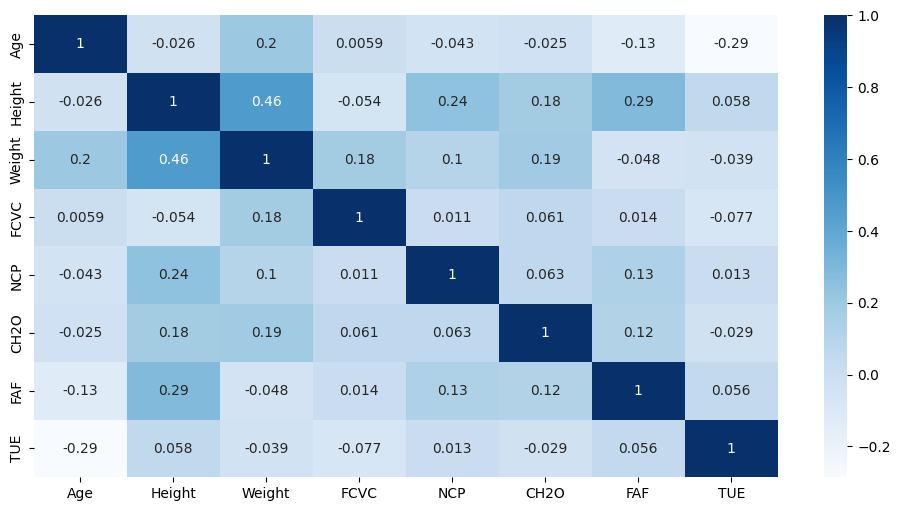

In [ ]:
# Correlação de variáveis contínuas

num_cols = obesity.select_dtypes(include = ["int64", "float64"]).columns
corr = obesity[num_cols].corr()
plt.figure(figsize = (12,6))
sns.heatmap(corr, cmap = "Blues", annot = True)

In [ ]:
obesity.duplicated().sum()

np.int64(27)

Criando algumas features

In [ ]:
obesity['imc'] = obesity['Weight'] / obesity['Height']**2
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [ ]:
obesity["Age_Group"] = pd.cut(
    obesity["Age"],
    bins=[0,25,40,100],
    labels=["Young","Adult","Older"]
)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young


In [ ]:
Age_Group_Code = obesity['Age_Group'].map({'Young':0, 'Adult':1, 'Older': 2})

In [ ]:
obesity["Healthy_Score"] = (
    obesity["FCVC"] +
    obesity["FAF"] +
    obesity["CH2O"]
)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4


In [ ]:
# Índice de Sedentarismo
# TUE = technology usage time
# FAF = physical activity frequency

obesity["Sedentary_Index"] = obesity["TUE"] / (obesity["FAF"] + 1)
obesity.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000


In [ ]:
# Fazer encoding manual, pois atividades tem pesos diferntes

activity_transport = {
    "Walking": 3,
    "Bike": 3,
    "Public_Transportation": 2,
    "Automobile": 1,
    'Motorbike': 1
}

obesity['MTRANS_Code'] = obesity['MTRANS'].map(activity_transport)
obesity.head(10)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2
5,Male,29,1.62,53.0,no,yes,2,3,Sometimes,no,2,no,0,0,Sometimes,Automobile,Normal_Weight,20.195092,Adult,4,0.000000,1
6,Female,23,1.50,55.0,yes,yes,3,3,Sometimes,no,2,no,1,0,Sometimes,Motorbike,Normal_Weight,24.444444,Young,6,0.000000,1
7,Male,22,1.64,53.0,no,no,2,3,Sometimes,no,2,no,3,0,Sometimes,Public_Transportation,Normal_Weight,19.705532,Young,7,0.000000,2
8,Male,24,1.78,64.0,yes,yes,3,3,Sometimes,no,2,no,1,1,Frequently,Public_Transportation,Normal_Weight,20.199470,Young,6,0.500000,2
9,Male,22,1.72,68.0,yes,yes,2,3,Sometimes,no,2,no,1,1,no,Public_Transportation,Normal_Weight,22.985398,Young,5,0.500000,2


In [ ]:
caec_freq = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

obesity['caec_code'] = obesity['CAEC'].map(caec_freq)
obesity.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,caec_code
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,1
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,1
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,1


In [ ]:
calc_freq = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

obesity['calc_code'] = obesity['CALC'].map(calc_freq)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,caec_code,calc_code
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1,0
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1,1
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,1,2
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,1,2
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,1,1


<Axes: >

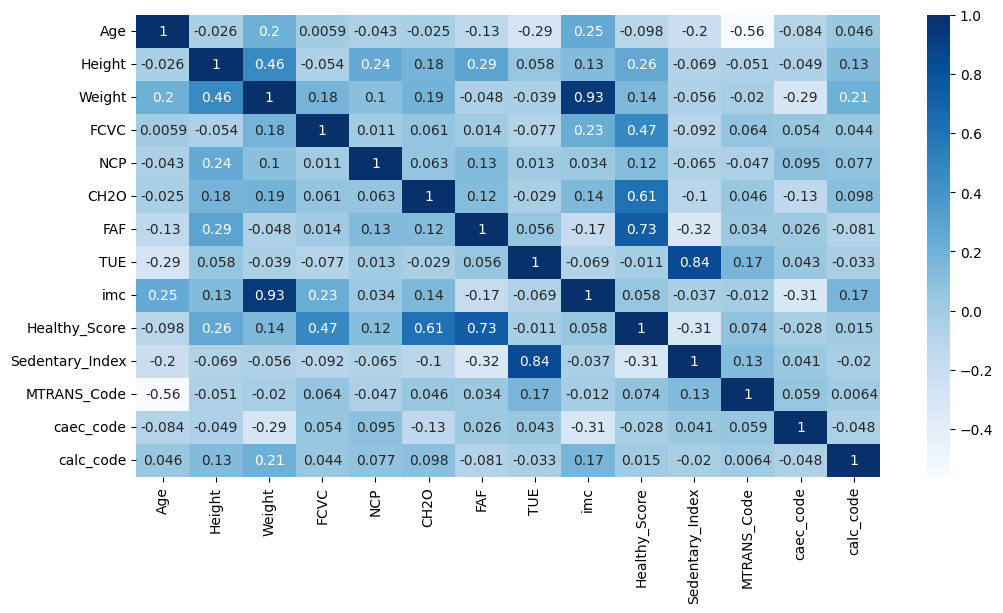

In [ ]:
# Correlação de variáveis contínuas

num_cols = obesity.select_dtypes(include = ["int64", "float64"]).columns
corr = obesity[num_cols].corr()
plt.figure(figsize = (12,6))
sns.heatmap(corr, cmap = "Blues", annot = True)

Encoding de variáveis categóricas ou binárias

In [ ]:
# Cria uma nova coluna 'gender_binary' a partir da coluna 'Gender'
obesity['gender_binary'] = obesity['Gender'].map({'Male': 0, 'Female': 1})
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,caec_code,calc_code,gender_binary
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1,0,1
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1,1,1
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,1,2,0
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,1,2,0
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,1,1,0


In [ ]:
# Bynary Encoding

import category_encoders as ce

binary_cols = ['family_history','FAVC', 'SMOKE', 'SCC' ]
encoder = ce.BinaryEncoder(cols = binary_cols)
obesity_encoded = encoder.fit_transform(obesity)
obesity_encoded

,Gender,Age,Height,Weight,family_history_0,family_history_1,FAVC_0,FAVC_1,FCVC,NCP,CAEC,SMOKE_0,SMOKE_1,CH2O,SCC_0,SCC_1,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,caec_code,calc_code,gender_binary
0,Female,21,1.620000,64.000000,0,1,0,1,2,3,Sometimes,0,1,2,0,1,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1,0,1
1,Female,21,1.520000,56.000000,0,1,0,1,3,3,Sometimes,1,0,3,1,0,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1,1,1
2,Male,23,1.800000,77.000000,0,1,0,1,2,3,Sometimes,0,1,2,0,1,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,1,2,0
3,Male,27,1.800000,87.000000,1,0,0,1,3,3,Sometimes,0,1,2,0,1,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,1,2,0
4,Male,22,1.780000,89.800000,1,0,0,1,2,1,Sometimes,0,1,2,0,1,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.710730,131.408528,0,1,1,0,3,3,Sometimes,0,1,2,0,1,2,1,Sometimes,Public_Transportation,Obesity_Type_III,44.901475,Young,7,0.333333,2,1,1,1
2107,Female,22,1.748584,133.742943,0,1,1,0,3,3,Sometimes,0,1,2,0,1,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.741923,Young,6,0.500000,2,1,1,1
2108,Female,23,1.752206,133.689352,0,1,1,0,3,3,Sometimes,0,1,2,0,1,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.543817,Young,6,0.500000,2,1,1,1
2109,Female,24,1.739450,133.346641,0,1,1,0,3,3,Sometimes,0,1,3,0,1,1,1,Sometimes,Public_Transportation,Obesity_Type_III,44.071535,Young,7,0.500000,2,1,1,1


<Axes: ylabel='Weight'>

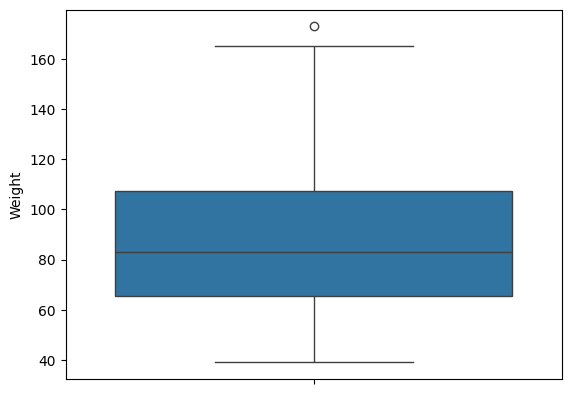

In [ ]:
# Outliers

sns.boxplot(obesity['Weight'])

<Axes: ylabel='Height'>

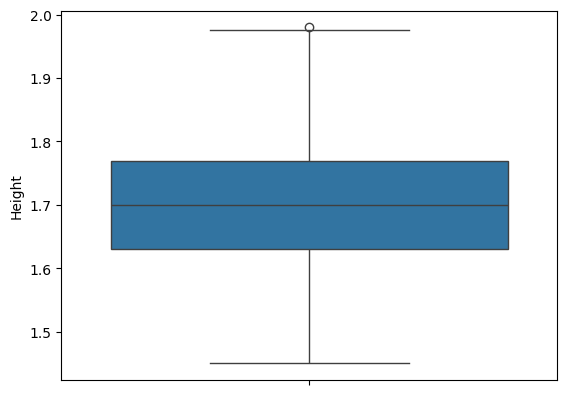

In [ ]:
sns.boxplot(obesity['Height'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
# Remover variáveis correlacionadas do modelo, mas para fazer o Streamlit, quero que o usuário informe os dados para ser possível construir as features derivadas
obesity_encoded = obesity_encoded.drop(['Weight', 'TUE', 'CH2O', 'FAF', 'FCVC'], axis=1)


In [ ]:
obesity_encoded.head()

,Gender,Age,Height,family_history_0,family_history_1,FAVC_0,FAVC_1,NCP,CAEC,SMOKE_0,SMOKE_1,SCC_0,SCC_1,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,caec_code,calc_code,gender_binary
0,Female,21,1.62,0,1,0,1,3,Sometimes,0,1,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1,0,1
1,Female,21,1.52,0,1,0,1,3,Sometimes,1,0,1,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1,1,1
2,Male,23,1.80,0,1,0,1,3,Sometimes,0,1,0,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,1,2,0
3,Male,27,1.80,1,0,0,1,3,Sometimes,0,1,0,1,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,1,2,0
4,Male,22,1.78,1,0,0,1,1,Sometimes,0,1,0,1,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,1,1,0


Modelagem

In [ ]:
# Importar bibliotecas
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Removere colunas originais que já foram codificadas
cols_to_drop = ["Gender",  "CAEC", "CALC", "MTRANS", "Age_Group"]

# Remove essas colunas antes do split
X = obesity_encoded.drop(cols_to_drop + ["Obesity"], axis=1)
y = obesity_encoded["Obesity"]

Separar em dados de treino, teste e validação

In [ ]:
from sklearn.model_selection import train_test_split

# Primeiro: separa treino + temp (validação+teste)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Depois: separa temp em validação e teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Tamanhos:")
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)


Tamanhos:
Treino: (1477, 18)
Validação: (317, 18)
Teste: (317, 18)


In [ ]:
# Definir colunas numéricas para padronização
num_cols = ["Height", "Age", "imc", "Healthy_Score",
            "Sedentary_Index", "NCP"]

# Criar o preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"  # mantém o resto das colunas como estão
)

In [ ]:

# Criar pipeline com LogisticRegression
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [ ]:
# Grade de hiperparâmetros para LogisticRegression
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],       # força da regularização
    "classifier__penalty": ["l2"],             # tipo de penalidade
    "classifier__solver": ["lbfgs", "saga"]    # algoritmos de otimização
}



In [ ]:
# GridSearch com cross-validation (5 folds)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


In [ ]:
# Treinar o modelo
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Height',
                                                                          'Age',
                                                                          'imc',
                                                                          'Healthy_Score',
                                                                          'Sedentary_Index',
                                                                          'NCP'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs', 'saga']},
             scoring='accuracy')

In [ ]:
# Resultados
print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor acurácia média (CV):", grid_search.best_score_)

Melhores parâmetros: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Melhor acurácia média (CV): 0.9444846541456711


In [ ]:

# Fazer previsões
# y_pred = pipeline.predict(X_test)

In [ ]:


# # Avaliar desempenho
# print("Acurácia:", accuracy_score(y_test, y_pred))
# print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))
# print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))


In [ ]:
# Previsões conjunto de validação

# y_val_pred = pipeline.predict(X_val)
# Avaliar no conjunto de validação
y_val_pred = grid_search.predict(X_val)
print("Acurácia validação:", accuracy_score(y_val, y_val_pred))

Acurácia validação: 0.943217665615142


In [ ]:


# Avaliar desempenho
print("Acurácia:", accuracy_score(y_val, y_val_pred))
print("\nRelatório de classificação:\n", classification_report(y_val, y_val_pred))
print("\nMatriz de confusão:\n", confusion_matrix(y_val, y_val_pred))


Acurácia: 0.943217665615142

Relatório de classificação:
                      precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        41
      Normal_Weight       0.91      0.91      0.91        43
     Obesity_Type_I       0.98      0.91      0.94        53
    Obesity_Type_II       0.96      1.00      0.98        44
   Obesity_Type_III       1.00      1.00      1.00        49
 Overweight_Level_I       0.90      0.84      0.87        44
Overweight_Level_II       0.87      0.95      0.91        43

           accuracy                           0.94       317
          macro avg       0.94      0.94      0.94       317
       weighted avg       0.94      0.94      0.94       317


Matriz de confusão:
 [[41  0  0  0  0  0  0]
 [ 1 39  0  0  0  3  0]
 [ 0  0 48  2  0  0  3]
 [ 0  0  0 44  0  0  0]
 [ 0  0  0  0 49  0  0]
 [ 0  4  0  0  0 37  3]
 [ 0  0  1  0  0  1 41]]


In [ ]:
import pandas as pd

# get trained logistic regression model
modelo_final = grid_search.best_estimator_.named_steps['classifier']

# coefficients
coeficientes = modelo_final.coef_[0]

# feature names after preprocessing
variaveis = grid_search.best_estimator_ \
    .named_steps['preprocessor'] \
    .get_feature_names_out()

# create dataframe
coef_df = pd.DataFrame({
    'Variable': variaveis,
    'Coefficient': coeficientes
})

# sort coefficients
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df)

                       Variable  Coefficient
15         remainder__caec_code     1.789675
6   remainder__family_history_0     0.756919
9             remainder__FAVC_1     0.603795
11           remainder__SMOKE_1     0.511100
13             remainder__SCC_1     0.351583
3            num__Healthy_Score     0.243777
5                      num__NCP    -0.100646
4          num__Sedentary_Index    -0.147851
12             remainder__SCC_0    -0.271766
17     remainder__gender_binary    -0.390268
10           remainder__SMOKE_0    -0.431282
16         remainder__calc_code    -0.447370
8             remainder__FAVC_0    -0.523978
7   remainder__family_history_1    -0.677101
0                   num__Height    -0.717070
14       remainder__MTRANS_Code    -0.784415
1                      num__Age    -1.079983
2                      num__imc   -31.288335


In [ ]:
print(grid_search.best_estimator_.named_steps)

{'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['Height', 'Age', 'imc', 'Healthy_Score',
                                  'Sedentary_Index', 'NCP'])]), 'classifier': LogisticRegression(C=10, max_iter=1000, random_state=42)}


In [ ]:
import joblib

# Salvar o objeto inteiro (inclui resultados da busca)
#joblib.dump(grid_search, "logreg_gridsearch.joblib")

# OU salvar apenas o melhor pipeline encontrado
joblib.dump(grid_search.best_estimator_, "logreg_best_pipeline.joblib")


['logreg_best_pipeline.joblib']

In [ ]:
import pkg_resources

# Lista apenas os pacotes que você realmente usou
packages = ["scikit-learn", "xgboost", "joblib", "pandas", "numpy"]

with open("requirements.txt", "w") as f:
    for pkg in packages:
        version = pkg_resources.get_distribution(pkg).version
        f.write(f"{pkg}=={version}\n")


/tmp/ipykernel_19831/1019826238.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
